# ST40 lithium-powder core transit: setup and smoke results

**Acceptance: PASS** · deterministic cohort: **30 grains** ·
OpenEdge axisymmetric geometry · 100 µm diameter · 1.0–1.5 m/s · ±15°.

**Size/timestep gate: PASS** ·
270 grains per timestep ·
9 diagnostic diameters from
40–300 µm.

**OML heat-scale gate: PASS** ·
270 grains at each of
7 multipliers from
0–2×.

This notebook answers a narrow setup question before a production campaign:
can a grain geometrically fall through the core, and what does the current
plasma/particulate model predict? It is a **smoke and verification result**, not
yet a converged experimental claim. The gravity-only case is an analytic oracle;
the physics case uses the orientation-verified SOLPS background, labelled core
extension, DUSTT-2005 drag/termination, OML heating, and no stochastic Li markers.

In [1]:
from pathlib import Path
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm, Normalize
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]):
    if (candidate / 'analysis/core_transit_acceptance.json').exists():
        ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError('Run scripts/analyze_core_transit_smoke.py first')

traj = pd.read_csv(ROOT / 'analysis/core_transit_trajectories.csv')
summary = pd.read_csv(ROOT / 'analysis/core_transit_cohort_summary.csv')
manifest = pd.read_csv(ROOT / 'input/core_transit_cohort.csv')
acceptance = json.loads((ROOT / 'analysis/core_transit_acceptance.json').read_text())
size_traj = pd.read_csv(ROOT / 'analysis/core_transit_size_scan_trajectories.csv')
size_summary = pd.read_csv(ROOT / 'analysis/core_transit_size_scan_summary.csv')
size_response = pd.read_csv(ROOT / 'analysis/core_transit_size_response.csv')
size_manifest = pd.read_csv(ROOT / 'input/core_transit_size_scan.csv')
size_acceptance = json.loads((ROOT / 'analysis/core_transit_size_scan_acceptance.json').read_text())
background = pd.read_csv(ROOT / 'analysis/core_transit_background_openedge.csv')
evap_segments = pd.read_csv(ROOT / 'analysis/core_transit_evaporation_segments.csv')
terminal_evap = pd.read_csv(ROOT / 'analysis/core_transit_terminal_evaporation.csv')
map_acceptance = json.loads((ROOT / 'analysis/core_transit_map_acceptance.json').read_text())
heat_summary = pd.read_csv(ROOT / 'analysis/core_transit_heat_scale_summary.csv')
heat_response = pd.read_csv(ROOT / 'analysis/core_transit_heat_scale_response.csv')
heat_aggregate = pd.read_csv(ROOT / 'analysis/core_transit_heat_scale_aggregate.csv')
heat_acceptance = json.loads((ROOT / 'analysis/core_transit_heat_scale_acceptance.json').read_text())

def read_wall(path):
    lines = path.read_text().splitlines(); i = lines.index('Points') + 1
    while not lines[i].strip(): i += 1
    points = []
    while i < len(lines) and lines[i].strip():
        _, z, r = lines[i].split(); points.append((float(z), float(r))); i += 1
    return np.asarray(points)

wall_zr = read_wall(ROOT / 'input/st40_wall_axi.surf')
with h5py.File(ROOT / 'input/plasma_st40_solps_corefill.h5', 'r') as h:
    r = h['r'][:]; z = h['z'][:]
    fill_mask = h['core_fill_mask'][:]
    te = h['temp_e'][:]; ne = h['dens_e'][:]
    q_fill = h['q_par'][:] if 'q_par' in h else None
    req = h['equilibrium/r'][:]; zeq = h['equilibrium/z'][:]
    psi = h['equilibrium/psi'][:]
    pa = float(h['equilibrium/psi_axis'][()]); pb = float(h['equilibrium/psib'][()])
    psi_n = (psi-pa)/(pb-pa)
    imported_heatflux_datasets = [name for name in
        ('q_par','q_perp','mesh/q_par','mesh/q_perp') if name in h]

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False, 'font.size': 10})
print('case root:', ROOT.name)

case root: st40_lithium_powder_dropper


## Machine-checked acceptance

In [2]:
checks = pd.DataFrame([
    ('overall smoke gate', acceptance['status'], 'all checks below'),
    ('gravity position oracle', 'PASS', f"max {acceptance['ballistic_max_position_error_m']:.3e} m"),
    ('gravity velocity oracle', 'PASS', f"max {acceptance['ballistic_max_velocity_error_m_s']:.3e} m/s"),
    ('surface-event classification', 'PASS', str(acceptance['wall_reaction_counts'])),
    ('physics Li inventory', 'PASS', f"closure {100*acceptance['physics_inventory']['closure_fraction']:.4f}%"),
], columns=['gate','result','evidence'])
display(checks.style.hide(axis='index'))

gate,result,evidence
overall smoke gate,PASS,all checks below
gravity position oracle,PASS,max 1.330e-11 m
gravity velocity oracle,PASS,max 2.577e-11 m/s
surface-event classification,PASS,"{'ballistic': 30, 'dustt2005_corefill': 4}"
physics Li inventory,PASS,closure 99.9874%


## Geometry, numerical core, and deterministic launches

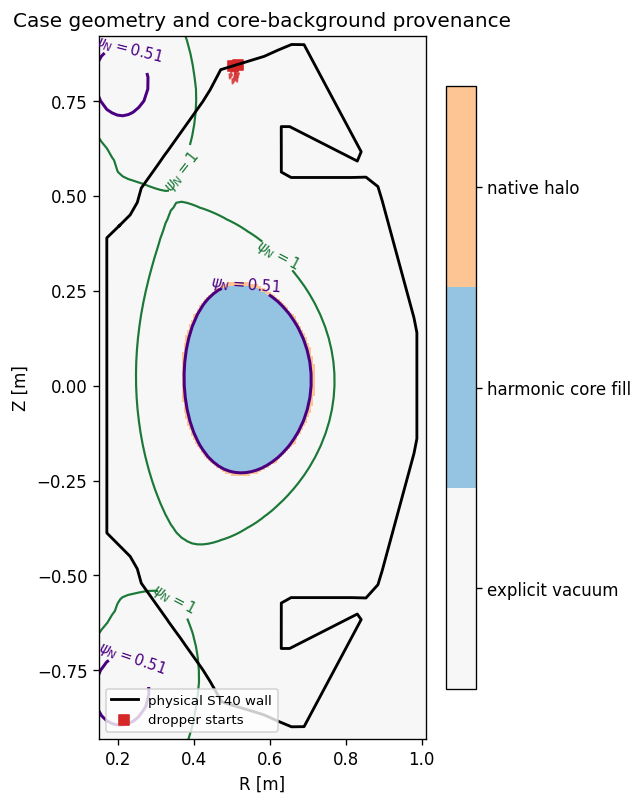

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 7.6))
cmap = ListedColormap(['#f4f4f4', '#6baed6', '#fdae6b'])
pm = ax.pcolormesh(r, z, fill_mask, shading='auto', cmap=cmap, vmin=0, vmax=2, alpha=.72)
cs = ax.contour(req, zeq, psi_n, levels=[.51, 1.0], colors=['#4b0082','#1b7837'],
                linewidths=[1.8,1.3])
ax.clabel(cs, fmt={.51:r'$\psi_N=0.51$',1.0:r'$\psi_N=1$'}, fontsize=9)
closed = np.vstack([wall_zr, wall_zr[0]])
ax.plot(closed[:,1], closed[:,0], 'k-', lw=1.7, label='physical ST40 wall')
drop = manifest.groupby('dropper_line').first()
ax.scatter(drop.r0_m, drop.z0_m, marker='s', s=42, color='#d62728', label='dropper starts')
for row in manifest[manifest.angle_deg.isin([-15,0,15])].iloc[::5].itertuples():
    ax.arrow(row.r0_m, row.z0_m, .035*row.vr0_m_s, .035*row.vz0_m_s,
             width=.0012, head_width=.009, color='#d62728', alpha=.7, length_includes_head=True)
ax.set(xlabel='R [m]', ylabel='Z [m]', aspect='equal', xlim=(.15,1.01), ylim=(-.93,.92),
       title='Case geometry and core-background provenance')
ax.legend(loc='lower left', fontsize=8)
labels = ['explicit vacuum','harmonic core fill','native halo']
cbar = fig.colorbar(pm, ax=ax, ticks=[1/3,1,5/3], fraction=.045, pad=.03)
cbar.ax.set_yticklabels(labels)
plt.show()

The physical wall is unchanged. The old artificial core surface is absent. Only atomic/ionic Li sees the species-selective $\psi_N=0.51$ sink; grains cross it.

## How the grains are initialized

In [4]:
initialization = (size_manifest.groupby(['diameter_um','radius_um'],as_index=False)
                  .agg(grains=('id','size'), mass_per_grain_kg=('mass_kg','first'),
                       atoms_per_grain=('atoms_per_grain','first')))
display(initialization.style.format({
    'mass_per_grain_kg':'{:.4e}', 'atoms_per_grain':'{:.4e}'}).hide(axis='index'))

launches = (size_manifest.groupby(['dropper_line','speed_m_s','angle_deg'])
            .size().rename('diameter_copies').reset_index())
print('OpenEdge read_particles rows:', len(size_manifest))
print('unique physical launch states:', len(launches))
print('diameter copies of every launch:', launches.diameter_copies.unique().tolist())
display(size_manifest[['id','species_type','species_id','diameter_um','z0_m','r0_m',
                       'vz0_m_s','vr0_m_s']].head(12))

diameter_um,radius_um,grains,mass_per_grain_kg,atoms_per_grain
40,20.000000,30,1.7895e-11,1.5528e+15
60,30.000000,30,6.0394e-11,5.2406e+15
80,40.000000,30,1.4316e-10,1.2422e+16
100,50.000000,30,2.7960e-10,2.4262e+16
125,62.500000,30,5.4610e-10,4.7387e+16
150,75.000000,30,9.4366e-10,8.1885e+16
200,100.000000,30,2.2368e-09,1.9410e+17
250,125.000000,30,4.3688e-09,3.7910e+17
300,150.000000,30,7.5492e-09,6.5508e+17


OpenEdge read_particles rows: 270
unique physical launch states: 30
diameter copies of every launch: [9]


,id,species_type,species_id,diameter_um,z0_m,r0_m,vz0_m_s,vr0_m_s
0,1,1,grain_d040um,40,0.841351,0.502956,-0.965926,-0.258819
1,2,1,grain_d040um,40,0.841351,0.502956,-0.991445,-0.130526
2,3,1,grain_d040um,40,0.841351,0.502956,-1.000000,0.000000
3,4,1,grain_d040um,40,0.841351,0.502956,-0.991445,0.130526
4,5,1,grain_d040um,40,0.841351,0.502956,-0.965926,0.258819
5,6,1,grain_d040um,40,0.841351,0.502956,-1.207407,-0.323524
6,7,1,grain_d040um,40,0.841351,0.502956,-1.239306,-0.163158
7,8,1,grain_d040um,40,0.841351,0.502956,-1.250000,0.000000
8,9,1,grain_d040um,40,0.841351,0.502956,-1.239306,0.163158
9,10,1,grain_d040um,40,0.841351,0.502956,-1.207407,0.323524


Each diameter is a distinct OpenEdge grain species. The species table supplies the initial radius, spherical mass at $\rho_{Li}=534$ kg m$^{-3}$, and 293.15 K temperature. The read-particles file supplies the persistent ID, species type, position, and velocity. Starts are 1 mm inside the two dropper wall segments; the full factorial launch grid is 2 segments × 3 speeds × 5 angles. Every diameter sees exactly the same 30 states. These equal diagnostic bins are **not** a measured ST40 powder-size distribution.

## Plasma actually sampled by OpenEdge

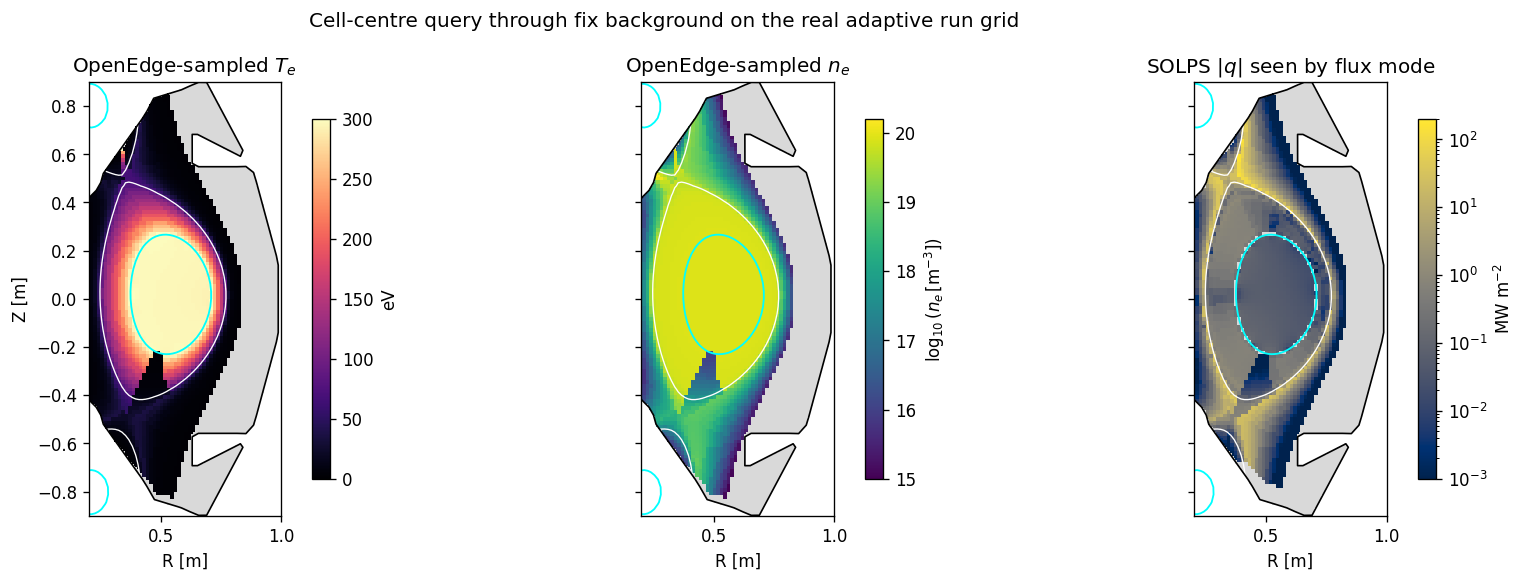

Imported q datasets: ['q_par', 'q_perp', 'mesh/q_par', 'mesh/q_perp']
OpenEdge q magnitude inside vessel [MW/m2]: 0.0 to 163.46514588251998
Explicit-vacuum OpenEdge cells inside wall (Te=ne=0): 1915
Synthetic core-fill Te [eV]: 285.8084544473541 to 299.65014902392255
Synthetic core-fill ne [m^-3]: 8.337872151006237e+19 to 8.397528389256248e+19
Synthetic core-fill q_parallel [MW/m2]: 0.003965090946228889 to 0.28644378559502565


In [5]:
inside = background[background.inside_vessel].copy()
fig, axes = plt.subplots(1,3,figsize=(15,4.9),sharex=True,sharey=True)
fields = [
    ('te_eV', r'OpenEdge-sampled $T_e$', 'eV', 'magma',
     lambda x: x, Normalize(vmin=0, vmax=300)),
    ('ne_m3', r'OpenEdge-sampled $n_e$', r'$\log_{10}(n_e\,[\mathrm{m}^{-3}])$',
     'viridis', np.log10, Normalize(vmin=15, vmax=20.2)),
    ('q_mag_W_m2', r'SOLPS $|q|$ seen by flux mode', r'MW m$^{-2}$', 'cividis',
     lambda x: x/1e6, LogNorm(vmin=1e-3, vmax=200)),
]
for ax, (column, title, label, cmap, transform, norm) in zip(axes, fields):
    all_patches = [Rectangle((row.R_m-row.dR_m/2, row.Z_m-row.dZ_m/2),
                             row.dR_m, row.dZ_m) for row in inside.itertuples()]
    ax.add_collection(PatchCollection(all_patches, facecolor='#d9d9d9',
                                      edgecolor='none', rasterized=True))
    shown = inside[inside[column] > 0].copy()
    patches = [Rectangle((row.R_m-row.dR_m/2, row.Z_m-row.dZ_m/2),
                         row.dR_m, row.dZ_m) for row in shown.itertuples()]
    values = transform(shown[column].to_numpy())
    pc = PatchCollection(patches, array=values, cmap=cmap, norm=norm,
                         linewidth=0, rasterized=True)
    ax.add_collection(pc)
    ax.contour(req,zeq,psi_n,levels=[.51,1],colors=['cyan','white'],linewidths=[1.1,.8])
    ax.plot(closed[:,1],closed[:,0],'k-',lw=1)
    ax.set(title=title,xlabel='R [m]',aspect='equal',xlim=(.2,1.0),ylim=(-.9,.9))
    fig.colorbar(pc,ax=ax,label=label,shrink=.83)
axes[0].set_ylabel('Z [m]')
fig.suptitle('Cell-centre query through fix background on the real adaptive run grid')
plt.tight_layout(); plt.show()

print('Imported q datasets:', imported_heatflux_datasets or 'none')
print('OpenEdge q magnitude inside vessel [MW/m2]:',
      inside.q_mag_W_m2.min()/1e6, 'to', inside.q_mag_W_m2.max()/1e6)
print('Explicit-vacuum OpenEdge cells inside wall (Te=ne=0):',
      int(((inside.te_eV == 0) & (inside.ne_m3 == 0)).sum()))
print('Synthetic core-fill Te [eV]:', te[fill_mask==1].min(), 'to', te[fill_mask==1].max())
print('Synthetic core-fill ne [m^-3]:', ne[fill_mask==1].min(), 'to', ne[fill_mask==1].max())
print('Synthetic core-fill q_parallel [MW/m2]:',
      q_fill[fill_mask==1].min()/1e6, 'to', q_fill[fill_mask==1].max()/1e6)

The plotted values come back through OpenEdge's background lookup on each actual adaptive-grid cell; they are not direct HDF5 images. This audit exposed and fixed a diagnostic mesh-only shortcut that had hidden the regular-grid core extension. Gray cells are explicit vacuum, rather than zeros passed through a logarithmic color map. The bright, nearly uniform central $T_e/n_e$ region is therefore **not a transpose or plotting artifact**: it is the labelled synthetic harmonic continuation inherited from the inner SOLPS boundary and must remain a sensitivity assumption. The physical SOLPS `q_par/q_perp` field, previously dropped by an equilibrium-only regeneration, is now restored; its much smaller core continuation is labelled separately. The present grain cases use `heating oml`, so prescribed flux remains diagnostic and is **not** their heat input.

## The decisive comparison: gravity-only geometry vs plasma physics

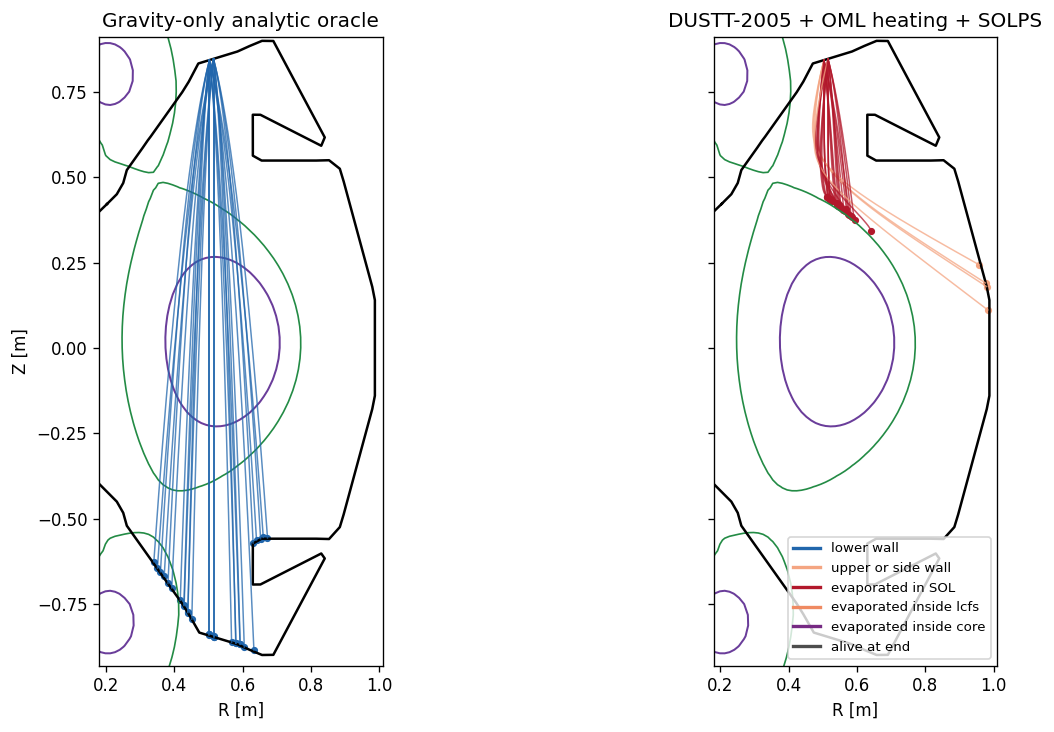

In [6]:
colors = {
    'lower_wall':'#2166ac',
    'upper_or_side_wall':'#f4a582',
    'evaporated_in_SOL':'#b2182b',
    'evaporated_inside_lcfs':'#ef8a62',
    'evaporated_inside_core':'#762a83',
    'alive_at_end':'#4d4d4d',
}
fig, axes = plt.subplots(1,2,figsize=(12.5,6.2),sharex=True,sharey=True)
for ax, case, title in zip(axes,
    ['ballistic','dustt2005_corefill'],
    ['Gravity-only analytic oracle','DUSTT-2005 + OML heating + SOLPS']):
    ax.contour(req,zeq,psi_n,levels=[.51,1],colors=['#6a3d9a','#238b45'],linewidths=[1.2,1])
    ax.plot(closed[:,1],closed[:,0],'k-',lw=1.5)
    subset = traj[traj.case==case]
    terminal = summary[summary.case==case].set_index('id')
    for pid, track in subset.groupby('id'):
        fate = terminal.loc[pid,'terminal_fate']
        ax.plot(track.R_m,track.Z_m,color=colors.get(fate,'.35'),lw=.9,alpha=.75)
        ax.scatter(track.R_m.iloc[-1],track.Z_m.iloc[-1],s=11,color=colors.get(fate,'.35'))
    ax.set(title=title,xlabel='R [m]',aspect='equal',xlim=(.18,1.01),ylim=(-.93,.91))
axes[0].set_ylabel('Z [m]')
from matplotlib.lines import Line2D
handles=[Line2D([0],[0],color=c,lw=2,label=k.replace('_',' ')) for k,c in colors.items()]
axes[1].legend(handles=handles,fontsize=8,loc='lower right')
plt.tight_layout(); plt.show()

In [7]:
outcomes = summary.groupby(['case','terminal_fate']).size().rename('grains').reset_index()
core = summary.groupby('case')[['entered_core','crossed_lower_core_alive']].sum().astype(int)
display(outcomes)
display(core)

,case,terminal_fate,grains
0,ballistic,lower_wall,30
1,dustt2005_corefill,evaporated_in_SOL,26
2,dustt2005_corefill,upper_or_side_wall,4


,entered_core,crossed_lower_core_alive
case,,
ballistic,30,30
dustt2005_corefill,0,0


## Where and how the physics grains disappear

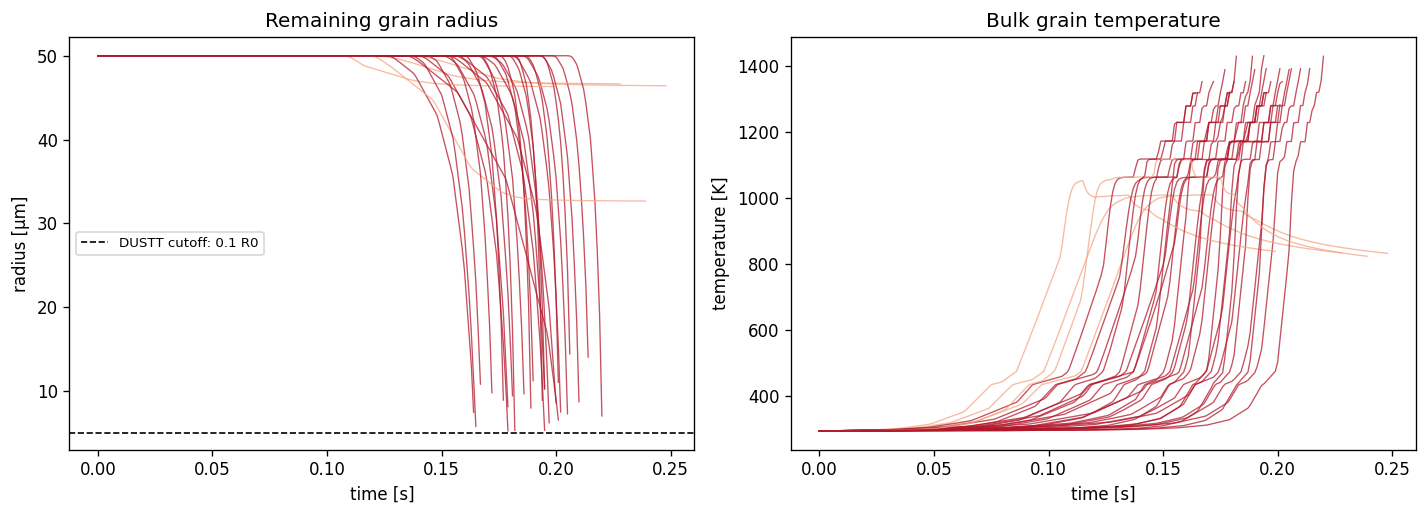

,speed_m_s,angle_deg,terminal_fate,last_time_s,last_Z_m,last_R_m,last_radius_um,min_psi_n
id,,,,,,,,
1,1.00,-15.0,upper_or_side_wall,0.248,0.1795,0.9791,46.4217,1.1871
2,1.00,-7.5,evaporated_in_SOL,0.195,0.4184,0.5474,5.3201,1.0428
3,1.00,0.0,evaporated_in_SOL,0.197,0.4315,0.5247,6.2194,1.0356
4,1.00,7.5,evaporated_in_SOL,0.205,0.4183,0.5403,7.2807,1.0291
5,1.00,15.0,evaporated_in_SOL,0.214,0.4015,0.5633,14.0460,1.0292
6,1.25,-15.0,upper_or_side_wall,0.228,0.1901,0.9759,46.6452,1.1816
7,1.25,-7.5,evaporated_in_SOL,0.179,0.4190,0.5470,5.2486,1.0436
8,1.25,0.0,evaporated_in_SOL,0.181,0.4348,0.5209,9.4388,1.0375
9,1.25,7.5,evaporated_in_SOL,0.190,0.4176,0.5420,11.2373,1.0303


In [8]:
phys = traj[traj.case=='dustt2005_corefill']
phys_summary = summary[summary.case=='dustt2005_corefill'].set_index('id')
fig, axes = plt.subplots(1,2,figsize=(12,4.4))
for pid, track in phys.groupby('id'):
    color=colors[phys_summary.loc[pid,'terminal_fate']]
    axes[0].plot(track.time_s,track.radius_m*1e6,color=color,lw=.8,alpha=.75)
    axes[1].plot(track.time_s,track.temperature_K,color=color,lw=.8,alpha=.75)
axes[0].axhline(5,color='k',ls='--',lw=1,label='DUSTT cutoff: 0.1 R0')
axes[0].set(xlabel='time [s]',ylabel='radius [µm]',title='Remaining grain radius')
axes[1].set(xlabel='time [s]',ylabel='temperature [K]',title='Bulk grain temperature')
axes[0].legend(fontsize=8)
plt.tight_layout();plt.show()

display(phys_summary[['speed_m_s','angle_deg','terminal_fate','last_time_s','last_Z_m',
                      'last_R_m','last_radius_um','min_psi_n']].round(4))

## DIS/DUSTT validity diagnostic: finite grain size relative to Debye length

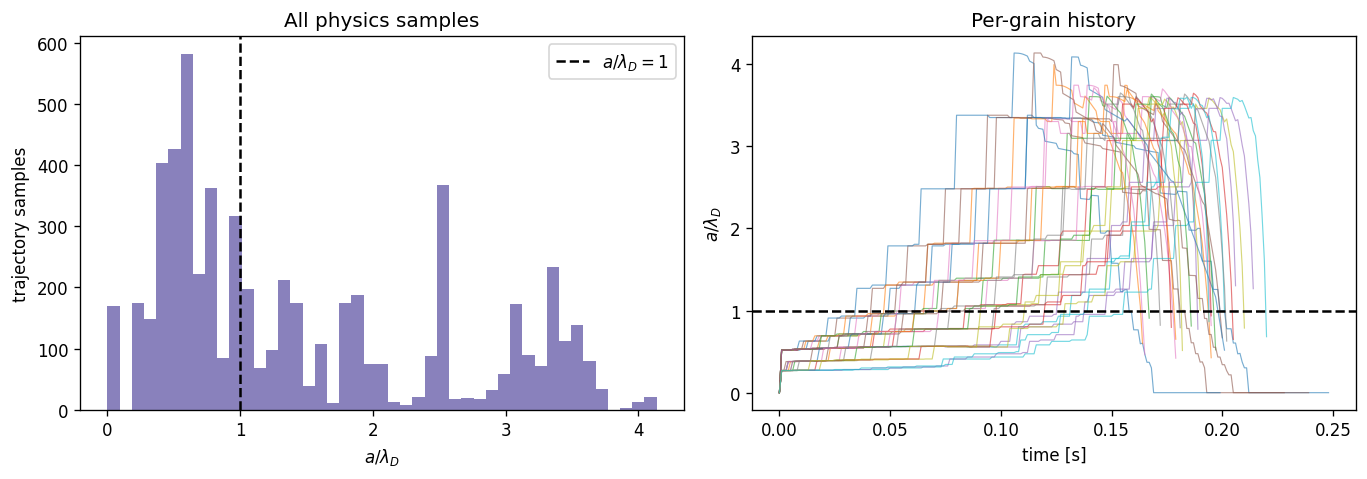

maximum a/lambda_D = 4.14
fraction of sampled states above 1 = 51.2%


In [9]:
valid = phys.a_over_lambdaD.replace([np.inf,-np.inf],np.nan).dropna()
fig, axes = plt.subplots(1,2,figsize=(11.5,4.1))
axes[0].hist(valid,bins=45,color='#756bb1',alpha=.85)
axes[0].axvline(1,color='k',ls='--',label=r'$a/\lambda_D=1$')
axes[0].set(xlabel=r'$a/\lambda_D$',ylabel='trajectory samples',title='All physics samples')
axes[0].legend()
for pid,track in phys.groupby('id'):
    axes[1].plot(track.time_s,track.a_over_lambdaD,lw=.7,alpha=.6)
axes[1].axhline(1,color='k',ls='--')
axes[1].set(xlabel='time [s]',ylabel=r'$a/\lambda_D$',title='Per-grain history')
plt.tight_layout();plt.show()
print(f"maximum a/lambda_D = {valid.max():.3g}")
print(f"fraction of sampled states above 1 = {(valid>1).mean():.1%}")

This is a quantified model-validity caveat, not a missing switch: DIS retains the OML surface potential and uses the finite-size Coulomb-log correction. The notebook reports the regime instead of silently replacing the model.

## Lithium inventory closure

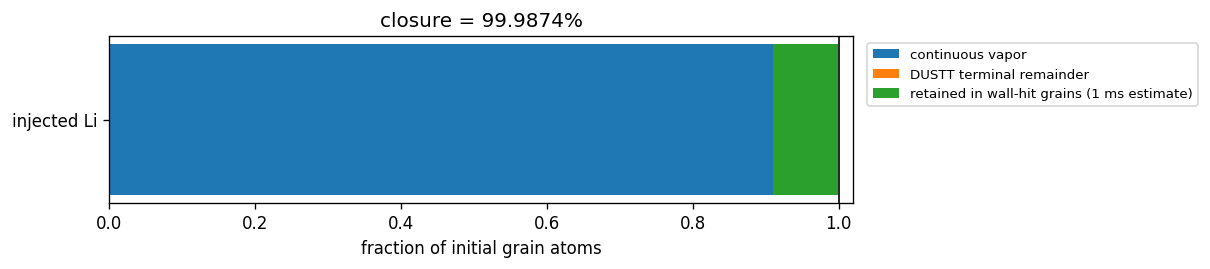

In [10]:
inv=acceptance['physics_inventory']
parts=pd.Series({
    'continuous vapor':inv['continuously_evaporated_atoms'],
    'DUSTT terminal remainder':inv['dustt_terminal_remainder_atoms'],
    'retained in wall-hit grains (1 ms estimate)':inv['wall_retained_atoms_estimate_from_1ms_last_state'],
})
fig,ax=plt.subplots(figsize=(8,1.8))
left=0
for label,value in parts.items():
    ax.barh(['injected Li'],[value/inv['initial_atoms']],left=left,label=label)
    left += value/inv['initial_atoms']
ax.axvline(1,color='k',lw=1)
ax.set(xlabel='fraction of initial grain atoms',xlim=(0,1.02),title=f"closure = {100*inv['closure_fraction']:.4f}%")
ax.legend(fontsize=8,bbox_to_anchor=(1.01,1),loc='upper left')
plt.show()

## Smoke conclusion

- **Geometry alone permits bottom transit:** 30/30 ballistic grains enter
  the core, cross its lower side alive, and hit the lower physical wall.
- **The present plasma case prevents it:** 0/30 physics grains enter the
  core; 26 evaporate in the SOL and
  4 are redirected to the upper/side wall.
- The physics inventory closes to **99.9874%** using the independent
  evaporation/remainder ledgers and the final 1 ms state of wall-hit grains.

This isolates the question cleanly: the artificial core boundary was not the
reason these baseline grains disappeared. Plasma heating and drag stop them
before the LCFS in this smoke setup.

## Grain-size response: does a larger grain cross the LCFS?

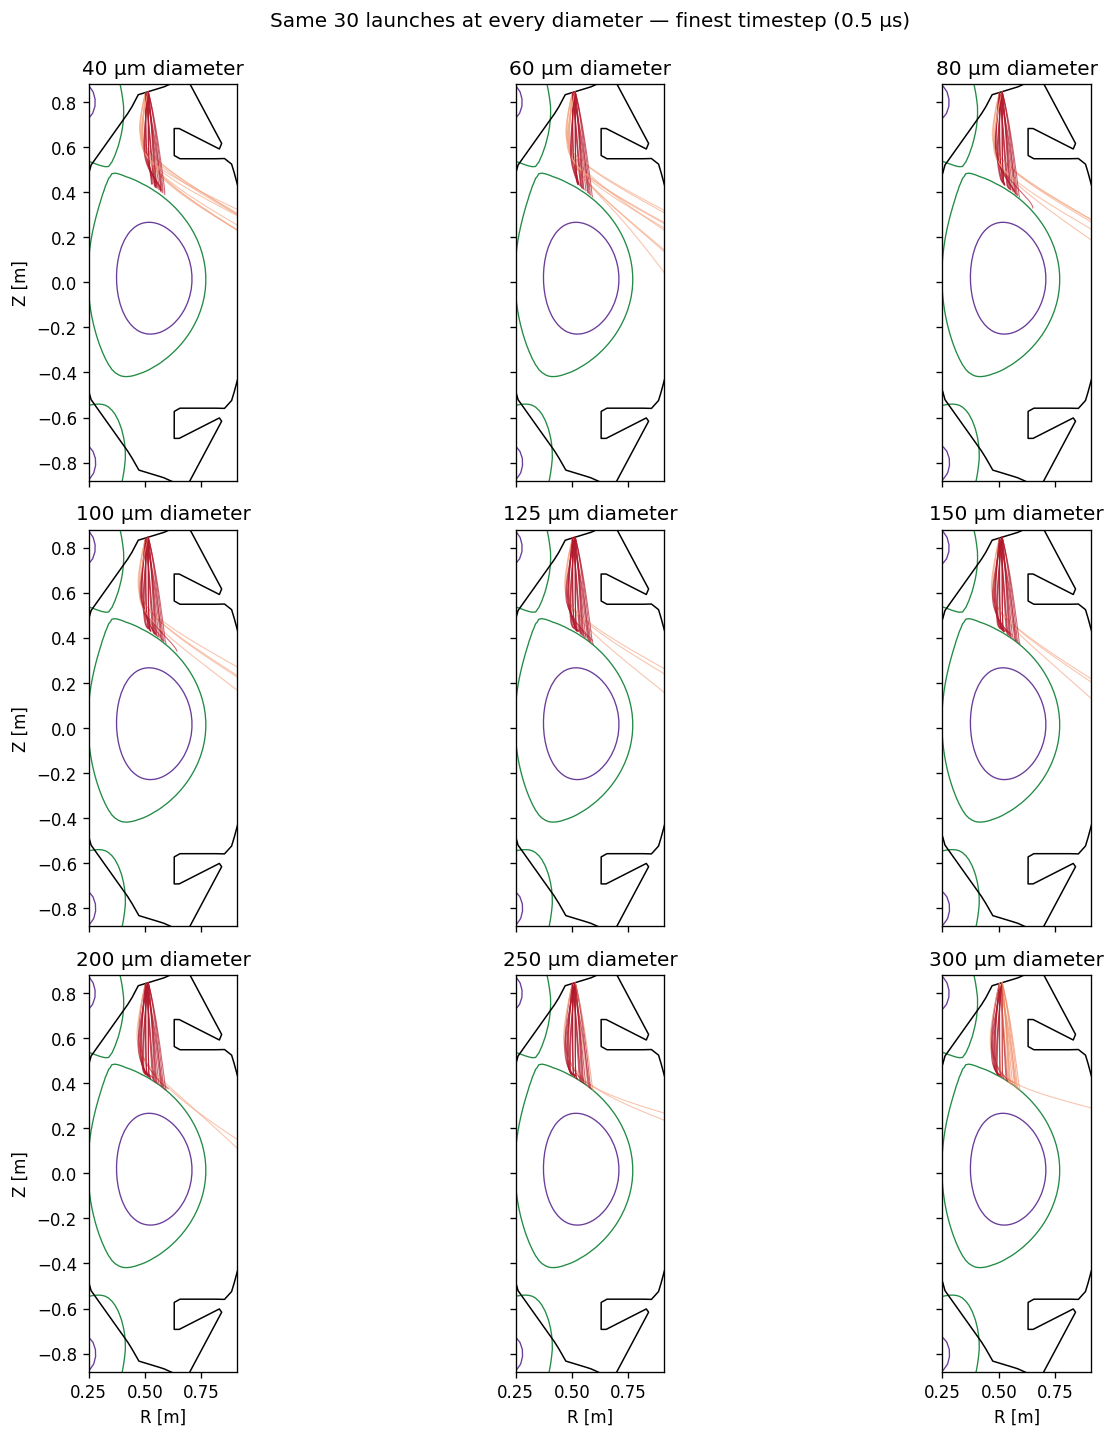

In [11]:
fine_case = 'dt0p5us'
fine_traj = size_traj[size_traj.case == fine_case]
fine_summary = size_summary[size_summary.case == fine_case]
diameters = sorted(fine_summary.diameter_um.unique())
fig, axes = plt.subplots(3,3,figsize=(12.5,12),sharex=True,sharey=True)
for ax, diameter in zip(axes.ravel(), diameters):
    subset = fine_traj[fine_traj.diameter_um == diameter]
    terminal = fine_summary[fine_summary.diameter_um == diameter].set_index('id')
    ax.contour(req,zeq,psi_n,levels=[.51,1],colors=['#6a3d9a','#238b45'],
               linewidths=[.8,.8])
    ax.plot(closed[:,1],closed[:,0],'k-',lw=.9)
    for pid,track in subset.groupby('id'):
        fate=terminal.loc[pid,'terminal_fate']
        ax.plot(track.R_m,track.Z_m,color=colors.get(fate,'.35'),lw=.65,alpha=.65)
    ax.set(title=f'{diameter:g} µm diameter',aspect='equal',xlim=(.25,.91),ylim=(-.88,.88))
for ax in axes[-1,:]: ax.set_xlabel('R [m]')
for ax in axes[:,0]: ax.set_ylabel('Z [m]')
fig.suptitle('Same 30 launches at every diameter — finest timestep (0.5 µs)',y=.995)
plt.tight_layout(); plt.show()

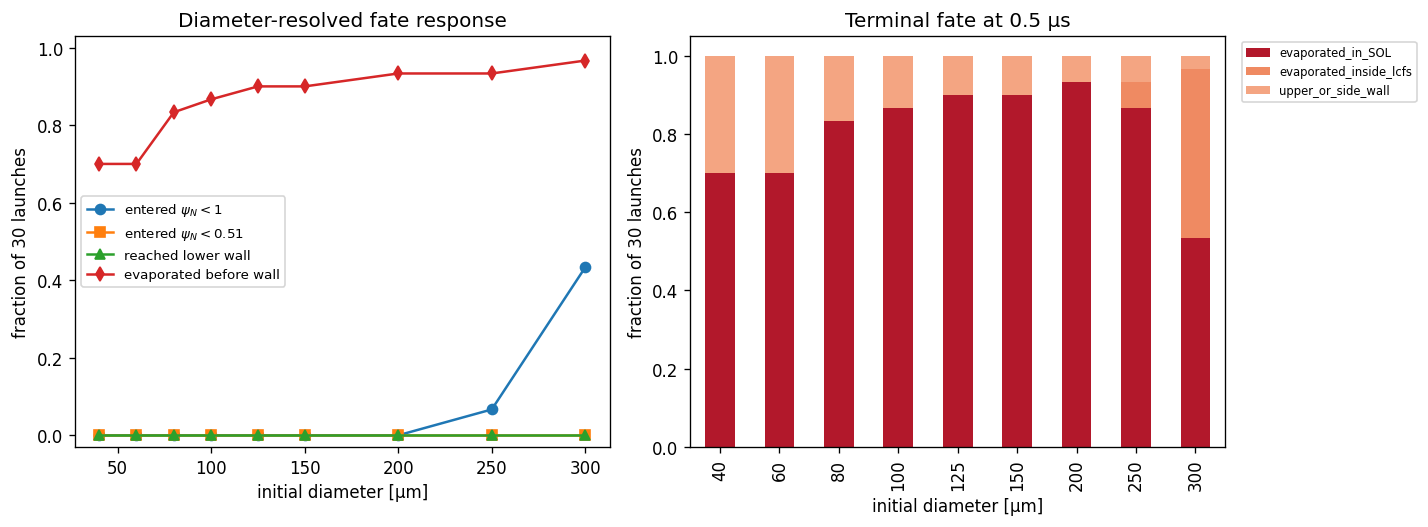

case,diameter_um,grains,entered_lcfs,entered_core,lower_wall,evaporated,median_min_psi_n,median_terminal_Z_m,median_max_temperature_K,entered_lcfs_fraction,entered_core_fraction,lower_wall_fraction,evaporated_fraction
dt0p5us,40,30,0,0,0,21,1.061600,0.408100,1279.781800,0.000000,0.000000,0.000000,0.700000
dt0p5us,60,30,0,0,0,21,1.051500,0.408900,1319.610100,0.000000,0.000000,0.000000,0.700000
dt0p5us,80,30,0,0,0,25,1.041700,0.408300,1319.610300,0.000000,0.000000,0.000000,0.833300
dt0p5us,100,30,0,0,0,26,1.034200,0.412700,1353.408700,0.000000,0.000000,0.000000,0.866700
dt0p5us,125,30,0,0,0,27,1.027700,0.414600,1389.740000,0.000000,0.000000,0.000000,0.900000
dt0p5us,150,30,0,0,0,27,1.022800,0.415400,1416.508800,0.000000,0.000000,0.000000,0.900000
dt0p5us,200,30,0,0,0,28,1.015900,0.418400,1449.710300,0.000000,0.000000,0.000000,0.933300
dt0p5us,250,30,2,0,0,28,1.008100,0.414400,1480.848300,0.066700,0.000000,0.000000,0.933300
dt0p5us,300,30,13,0,0,29,1.002500,0.414900,1492.916600,0.433300,0.000000,0.000000,0.966700


In [12]:
fine_response = size_response[size_response.case==fine_case].sort_values('diameter_um')
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for column,label,marker in [
    ('entered_lcfs_fraction',r'entered $\psi_N<1$','o'),
    ('entered_core_fraction',r'entered $\psi_N<0.51$','s'),
    ('lower_wall_fraction','reached lower wall','^'),
    ('evaporated_fraction','evaporated before wall','d')]:
    axes[0].plot(fine_response.diameter_um,fine_response[column],marker=marker,label=label)
axes[0].set(xlabel='initial diameter [µm]',ylabel='fraction of 30 launches',ylim=(-.03,1.03),
            title='Diameter-resolved fate response')
axes[0].legend(fontsize=8)

fates=(fine_summary.groupby(['diameter_um','terminal_fate']).size()
       .unstack(fill_value=0).div(30))
fates.plot.bar(stacked=True,ax=axes[1],color=[colors.get(c,'.5') for c in fates.columns])
axes[1].set(xlabel='initial diameter [µm]',ylabel='fraction of 30 launches',
            title='Terminal fate at 0.5 µs')
axes[1].legend(title='',fontsize=7,bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout();plt.show()
display(fine_response.round(4).style.hide(axis='index'))

## Where OpenEdge heats and evaporates the grains

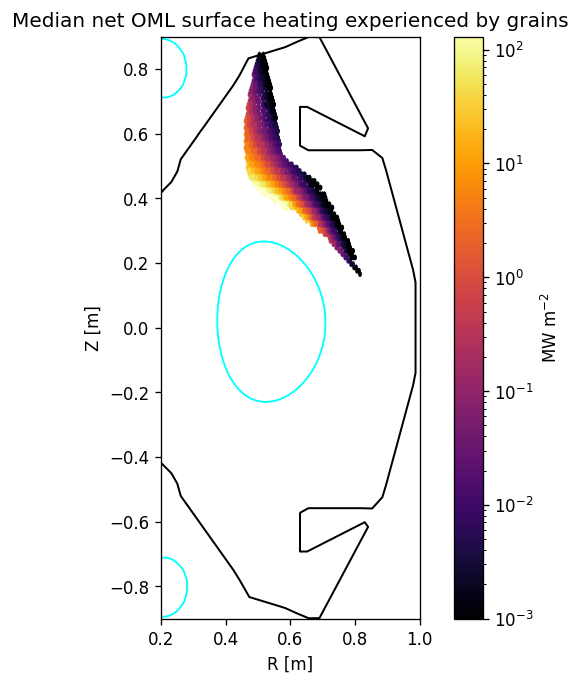

sampled net OML heating [MW/m2] percentiles:


,MW/m2
0.000,0.000000
0.500,0.015548
0.900,5.291394
0.990,90.109503
0.999,301.444146
1.000,495.760130


In [13]:
fig, ax = plt.subplots(figsize=(7.3,6.3))
hot = fine_traj[fine_traj.heating_W_m2 > 0]
hb = ax.hexbin(hot.R_m, hot.Z_m, C=hot.heating_W_m2/1e6, gridsize=58,
               reduce_C_function=np.median, mincnt=1,
               norm=LogNorm(vmin=max(.001,np.percentile(hot.heating_W_m2/1e6,2)),
                            vmax=np.percentile(hot.heating_W_m2/1e6,99.5)),
               cmap='inferno')
ax.contour(req,zeq,psi_n,levels=[.51,1],colors=['cyan','white'],linewidths=[1.1,.8])
ax.plot(closed[:,1],closed[:,0],'k-',lw=1.2)
ax.set(xlabel='R [m]',ylabel='Z [m]',aspect='equal',xlim=(.2,1.0),ylim=(-.9,.9),
       title='Median net OML surface heating experienced by grains')
fig.colorbar(hb,ax=ax,label=r'MW m$^{-2}$')
plt.show()
print('sampled net OML heating [MW/m2] percentiles:')
display((fine_traj.heating_W_m2/1e6).quantile([0,.5,.9,.99,.999,1]).to_frame('MW/m2'))

This is the heat flux actually integrated by `particulate/thermal`, after OML collection and the current `heatflux/scale=1`. It is sampled only where grains travel, unlike the full-domain prescribed-flux panel above.

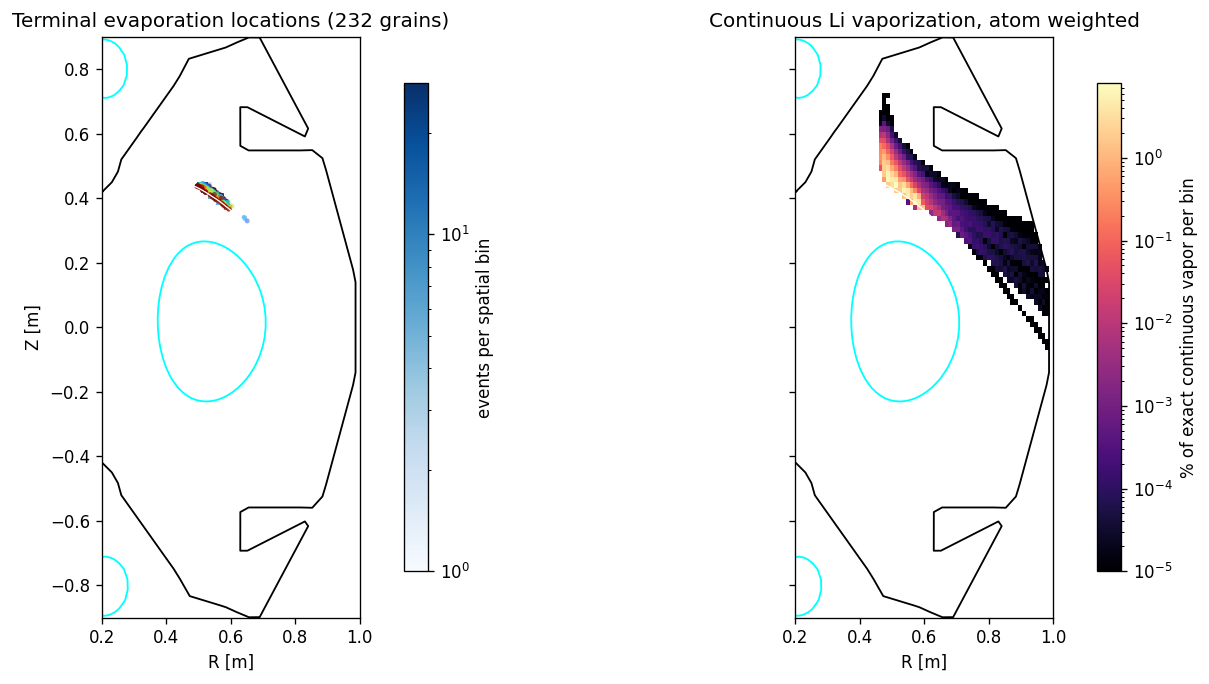

,terminal_events,vapor_atom_fraction
diameter_um,,
40,21,0.08%
60,21,0.31%
80,25,0.79%
100,26,1.59%
125,27,3.19%
150,27,5.58%
200,28,13.93%
250,28,27.31%
300,29,47.21%


status,source_case,dump_interval_s,terminal_evaporation_events,exact_continuous_vapor_atoms,trajectory_reconstructed_atoms_raw,trajectory_capture_fraction,map_normalization_factor,weighting_guard,spatial_inventory,background_query
PASS,dt0p5us,0.001000,232,41586000000000000000.000000,41585941919789506560.000000,0.999999,1.000001,The map is Li-atom weighted within an equal-count diagnostic diameter scan; it is not weighted by a measured ST40 size distribution.,"{'atom_weighted_centroid_R_m': 0.5239109789513009, 'atom_weighted_centroid_Z_m': 0.44237492121374433, 'vapor_fraction_in_SOL_psi_ge_1': 0.9916356400187296, 'vapor_fraction_inside_LCFS_0p51_to_1': 0.008364359981270272, 'vapor_fraction_inside_core_psi_lt_0p51': 0.0}","{'status': 'PASS', 'adaptive_cells_total': 10638, 'cells_inside_vessel': 5275, 'central_audit_cells': 84, 'central_te_eV_range': [295.64274667837, 296.70605631828], 'central_ne_m3_range': [8.3805014652178e+19, 8.385098373739e+19], 'imported_heatflux_datasets': ['q_par', 'q_perp', 'mesh/q_par', 'mesh/q_perp'], 'q_mag_W_m2_range_inside': [0.0, 163465145.88252], 'q_mag_W_m2_quantiles_inside': {'0.0': 0.0, '0.1': 0.0, '0.5': 8084.7945276501, '0.9': 1655029.0228421825, '0.99': 36439949.765627734, '1.0': 163465145.88252}, 'q_nonzero_cells_inside': 3247, 'q_vector_identity_max_abs_error_W_m2': 0.0, 'central_q_mag_W_m2_range': [47872.95584688, 85324.831782414], 'interpretation': 'The native SOLPS q field was restored after the equilibrium-only conversion dropped it. The central regular-grid carrier is an explicitly labelled harmonic continuation. Accepted trajectories use OML heating, so prescribed q remains a diagnostic.'}"


,value
atom_weighted_centroid_R_m,0.523911
atom_weighted_centroid_Z_m,0.442375
vapor_fraction_in_SOL_psi_ge_1,0.991636
vapor_fraction_inside_LCFS_0p51_to_1,0.008364
vapor_fraction_inside_core_psi_lt_0p51,0.000000


In [14]:
R_edges=np.linspace(.17,1.0,70); Z_edges=np.linspace(-.9,.9,105)
count,_,_=np.histogram2d(terminal_evap.R_m,terminal_evap.Z_m,bins=[R_edges,Z_edges])
atoms,_,_=np.histogram2d(evap_segments.R_m,evap_segments.Z_m,
    bins=[R_edges,Z_edges],weights=100*evap_segments.fraction_of_exact_vapor)

fig,axes=plt.subplots(1,2,figsize=(13.5,5.8),sharex=True,sharey=True)
for ax in axes:
    ax.contour(req,zeq,psi_n,levels=[.51,1],colors=['cyan','white'],linewidths=[1.1,.8])
    ax.plot(closed[:,1],closed[:,0],'k-',lw=1.1)
    ax.set(xlabel='R [m]',aspect='equal',xlim=(.2,1.0),ylim=(-.9,.9))
axes[0].set_ylabel('Z [m]')
im0=axes[0].pcolormesh(R_edges,Z_edges,np.ma.masked_equal(count.T,0),
    shading='flat',cmap='Blues',norm=LogNorm(vmin=1,vmax=max(2,count.max())))
axes[0].scatter(terminal_evap.R_m,terminal_evap.Z_m,c=terminal_evap.diameter_um,
    s=9,cmap='turbo',alpha=.65,edgecolor='none')
axes[0].set_title(f'Terminal evaporation locations ({len(terminal_evap)} grains)')
fig.colorbar(im0,ax=axes[0],label='events per spatial bin',shrink=.84)

positive=atoms[atoms>0]
im1=axes[1].pcolormesh(R_edges,Z_edges,np.ma.masked_equal(atoms.T,0),
    shading='flat',cmap='magma',norm=LogNorm(vmin=max(positive.min(),1e-5),vmax=positive.max()))
axes[1].set_title('Continuous Li vaporization, atom weighted')
fig.colorbar(im1,ax=axes[1],label='% of exact continuous vapor per bin',shrink=.84)
plt.tight_layout();plt.show()

evap_by_size=(terminal_evap.groupby('diameter_um').size().rename('terminal_events').to_frame()
    .join(evap_segments.groupby('diameter_um').evaporated_atoms.sum()
          .div(evap_segments.evaporated_atoms.sum()).rename('vapor_atom_fraction')))
display(evap_by_size.style.format({'vapor_atom_fraction':'{:.2%}'}))
display(pd.DataFrame([map_acceptance]).style.hide(axis='index'))
display(pd.Series(map_acceptance['spatial_inventory'],name='value').to_frame())

The left map is a grain-count view using the last 1-ms state before DUSTT termination. The right map distributes the continuous radius-cubed loss along every trajectory and includes the final loss down to the DUSTT $0.1R_0$ cutoff; the separate breakup remainder is excluded. The reconstruction captures 99.99986% of OpenEdge's exact vapor ledger before a 1.0000014 normalization. Because every diagnostic diameter has 30 launches, neither panel represents a measured ST40 powder-size distribution.

## Is the assumed OML heating stopping core transit?

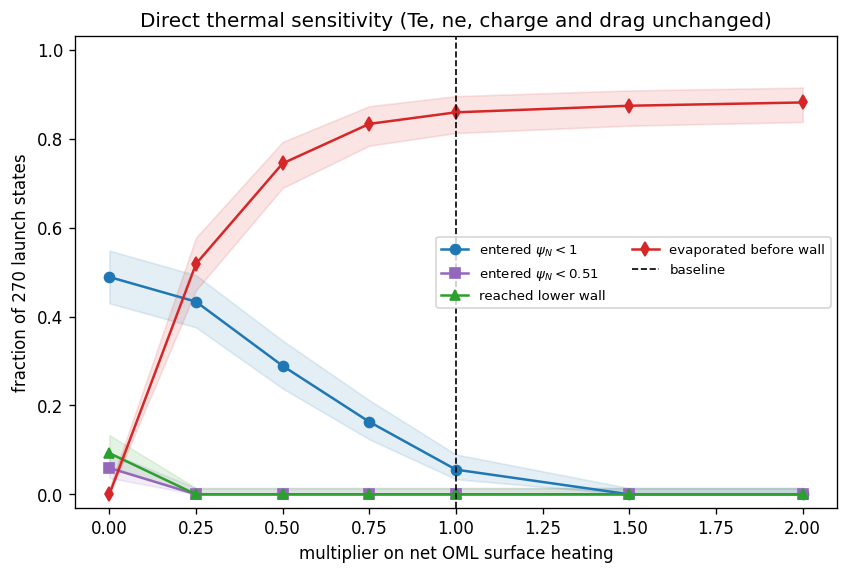

case,heat_scale,grains,entered_lcfs,entered_core,lower_wall,evaporated,entered_lcfs_fraction,entered_lcfs_lo95,entered_lcfs_hi95,entered_core_fraction,entered_core_lo95,entered_core_hi95,lower_wall_fraction,lower_wall_lo95,lower_wall_hi95,evaporated_fraction,evaporated_lo95,evaporated_hi95
hs000,0.000000,270,132,16,25,0,48.9%,43.0%,54.8%,5.9%,3.7%,9.4%,9.3%,6.4%,13.3%,0.0%,0.0%,1.4%
hs025,0.250000,270,117,0,0,140,43.3%,37.6%,49.3%,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,51.9%,45.9%,57.7%
hs050,0.500000,270,78,0,0,201,28.9%,23.8%,34.6%,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,74.4%,68.9%,79.3%
hs075,0.750000,270,44,0,0,225,16.3%,12.4%,21.2%,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,83.3%,78.4%,87.3%
hs100,1.000000,270,15,0,0,232,5.6%,3.4%,9.0%,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,85.9%,81.3%,89.6%
hs150,1.500000,270,0,0,0,236,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,87.4%,82.9%,90.8%
hs200,2.000000,270,0,0,0,238,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,0.0%,0.0%,1.4%,88.1%,83.7%,91.5%


In [15]:
heat_aggregate = heat_aggregate.sort_values('heat_scale')
metrics=[
    ('entered_lcfs',r'entered $\psi_N<1$','#1f77b4','o'),
    ('entered_core',r'entered $\psi_N<0.51$','#9467bd','s'),
    ('lower_wall','reached lower wall','#2ca02c','^'),
    ('evaporated','evaporated before wall','#d62728','d'),
]
fig,ax=plt.subplots(figsize=(8.2,5.1))
for metric,label,color,marker in metrics:
    x=heat_aggregate.heat_scale.to_numpy()
    y=heat_aggregate[f'{metric}_fraction'].to_numpy()
    lo=heat_aggregate[f'{metric}_lo95'].to_numpy()
    hi=heat_aggregate[f'{metric}_hi95'].to_numpy()
    ax.plot(x,y,marker=marker,color=color,label=label)
    ax.fill_between(x,lo,hi,color=color,alpha=.12)
ax.axvline(1,color='k',ls='--',lw=1,label='baseline')
ax.set(xlabel='multiplier on net OML surface heating',ylabel='fraction of 270 launch states',
       ylim=(-.03,1.03),title='Direct thermal sensitivity (Te, ne, charge and drag unchanged)')
ax.legend(fontsize=8,ncol=2)
plt.show()
display(heat_aggregate.style.format({c:'{:.1%}' for c in heat_aggregate.columns
    if c.endswith('_fraction') or c.endswith('_lo95') or c.endswith('_hi95')}).hide(axis='index'))

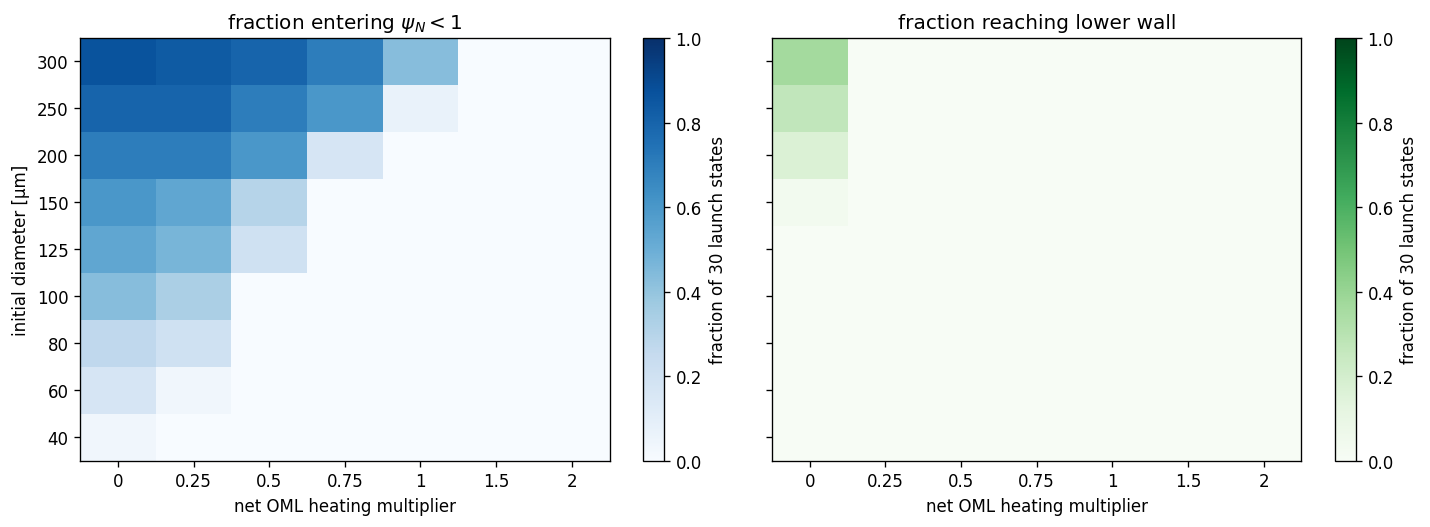

scales with any core entry:


,heat_scale,entered_core,grains
0,0.0,16,270


scales with any lower-wall arrival:


,heat_scale,lower_wall,grains
0,0.0,25,270


acceptance: PASS | baseline reproduces original: True


In [16]:
fig,axes=plt.subplots(1,2,figsize=(12.2,4.5),sharey=True)
for ax,column,title,cmap in [
    (axes[0],'entered_lcfs_fraction',r'fraction entering $\psi_N<1$','Blues'),
    (axes[1],'lower_wall_fraction','fraction reaching lower wall','Greens')]:
    table=(heat_response.pivot(index='diameter_um',columns='heat_scale',values=column)
           .sort_index(ascending=True))
    image=ax.imshow(table.to_numpy(),origin='lower',aspect='auto',vmin=0,vmax=1,cmap=cmap)
    ax.set_xticks(np.arange(len(table.columns)),[f'{value:g}' for value in table.columns])
    ax.set_yticks(np.arange(len(table.index)),[f'{value:g}' for value in table.index])
    ax.set(xlabel='net OML heating multiplier',title=title)
    fig.colorbar(image,ax=ax,label='fraction of 30 launch states')
axes[0].set_ylabel('initial diameter [µm]')
plt.tight_layout();plt.show()

nonzero_core=heat_aggregate.loc[heat_aggregate.entered_core>0,
                                ['heat_scale','entered_core','grains']]
nonzero_lower=heat_aggregate.loc[heat_aggregate.lower_wall>0,
                                 ['heat_scale','lower_wall','grains']]
print('scales with any core entry:')
display(nonzero_core if len(nonzero_core) else Markdown('none'))
print('scales with any lower-wall arrival:')
display(nonzero_lower if len(nonzero_lower) else Markdown('none'))
print('acceptance:',heat_acceptance['status'],
      '| baseline reproduces original:',heat_acceptance['baseline_reproduces_dt2us'])

This is a deliberately direct sensitivity: `heatflux/scale` multiplies the net OML surface heating after collection is evaluated. It answers whether the thermal term controls the fate transition, but it is **not** a self-consistent cooler-plasma case because charging and drag still see the original Te/ne. A profile-level Te/ne bracket is the next test if the transition lies near 1x. The shaded Wilson intervals describe the finite deterministic launch matrix, not experimental uncertainty.

## Does the evaporation result depend on the outer timestep?

In [17]:
conv=pd.DataFrame(size_acceptance['convergence'])
integrity=(pd.DataFrame(size_acceptance['integrity']).T
           [['wall_reactions','classified_wall_events','closure_fraction']])
display(conv.style.format({
    'fate_match_fraction':'{:.4f}', 'lcfs_entry_match_fraction':'{:.4f}',
    'core_entry_match_fraction':'{:.4f}',
    'terminal_position_delta_mm_median':'{:.4f}',
    'terminal_position_delta_mm_p95':'{:.4f}',
    'terminal_position_delta_mm_max':'{:.4f}',
    'last_sample_time_delta_ms_p95':'{:.4f}',
    'last_sample_time_delta_ms_max':'{:.4f}',
    'last_radius_delta_over_initial_p95':'{:.3%}',
    'last_radius_delta_over_initial_max':'{:.3%}'}).hide(axis='index'))
display(integrity.style.format({'closure_fraction':'{:.6f}'}))

coarse,fine,fate_match_fraction,lcfs_entry_match_fraction,core_entry_match_fraction,terminal_position_delta_mm_median,terminal_position_delta_mm_p95,terminal_position_delta_mm_max,last_sample_time_delta_ms_p95,last_sample_time_delta_ms_max,last_radius_delta_over_initial_p95,last_radius_delta_over_initial_max
dt2us,dt1us,1.0000,1.0000,1.0000,0.0011,0.0093,0.4230,0.0000,0.0000,0.005%,0.027%
dt1us,dt0p5us,1.0000,1.0000,1.0000,0.0009,0.0054,0.5026,0.0000,0.0000,0.007%,0.035%


,wall_reactions,classified_wall_events,closure_fraction
dt2us,38.000000,38.000000,1.000002
dt1us,38.000000,38.000000,1.000001
dt0p5us,38.000000,38.000000,1.000001


The OpenEdge thermal update uses symmetric half-steps and adaptive internal substeps capped at 25 K and 2% radius loss. The 2/1/0.5-µs comparison above is still required because particle motion and background sampling occur at the outer timestep. The gate requires identical fate and LCFS/core-entry decisions, small terminal-location changes, and closed material inventories.

## What must pass before a production conclusion

1. Apply the measured ST40 number- or mass-size distribution to the resolved size response.
2. Densify the deterministic speed/angle cohort around any fate-transition diameter.
3. Bracket uncertainty in the **SOL** $T_e$, $n_e$, flow, and launch location; the
   synthetic core fill is not yet active for this baseline because no grain reaches it.
4. Compare the retained DUSTT-2005 baseline with `model dis2021` as a separate
   particulate-model sensitivity.
5. Only after those gates pass, restore stochastic Li marker emission and chemistry.